In [6]:
import sys
sys.path.append("../")

from config import *
from figs_config import *
import run_wrappers
from interpmodules import helpers, metrics

Loaded aesthetics module


# GRF
This section contains code for visualizing **GRF instances**, **sampling regimes**, and for conducting **variography**

In [5]:
space = 'fsLR-4k'
datasource='grf'
geometry = 'sphere'
strategy = 'random'
niters = 100

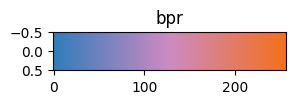

In [3]:
bpr,_ = three_colours_gradient(lo=plt.cm.Blues(0.7), mid=plt.cm.PuRd(0.4), hi=plt.cm.Oranges(0.6), plot=False)
show_colour_scheme(bpr, "bpr")

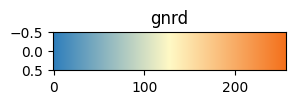

In [4]:
gnrd,_ = three_colours_gradient(lo=plt.cm.Blues(0.7), mid=plt.cm.YlOrBr(0.1), hi=plt.cm.Oranges(0.6), plot=False)
show_colour_scheme(gnrd, "gnrd")

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('Blues')
range_colours = lincmap(np.linspace(0.4, .7, len(test_percentages)))
sns.color_palette(range_colours)

[(0.5796078431372549, 0.7701960784313725, 0.8737254901960784),
 (0.41708573625528644, 0.6806305267204922, 0.8382314494425221),
 (0.2909803921568628, 0.5945098039215686, 0.7890196078431373),
 (0.1791464821222607, 0.49287197231833907, 0.7354248366013072)]

In [13]:
# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('YlOrBr')
pct_colours = lincmap(np.linspace(0.3, .6, len(test_percentages)))
sns.color_palette(pct_colours)

[(0.996078431372549, 0.8434755863129565, 0.4691580161476355),
 (0.996078431372549, 0.7349019607843138, 0.28),
 (0.9949711649365629, 0.5974778931180315, 0.15949250288350636),
 (0.939607843137255, 0.4713725490196078, 0.09490196078431372)]

* load data

In [7]:
import joblib
sphere_mesh = joblib.load(projdir + '/data/fsLR-4k_sphere_grf.pkl')

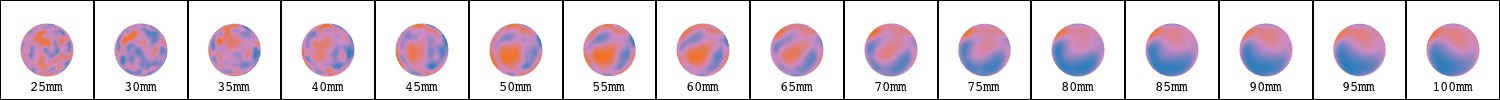

In [8]:
import copy
import pyvista as pv

pl = pv.Plotter(shape = (1,len(np.arange(25,105,5))), window_size = (1500,100))

for ri, r in enumerate(np.arange(25,105,5)):
    pl.subplot(0,ri)
    tmp_mesh = copy.deepcopy(sphere_mesh)
    pl.add_mesh(tmp_mesh, scalars = str(r), cmap = bpr, **mesh_aes)
    pl.add_text(str(r) + "mm", position = "lower_edge", font = "courier", font_size = 6)
    pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

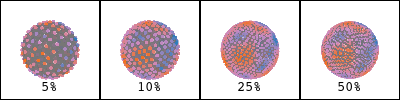

In [9]:
import copy
import pyvista as pv

pl = pv.Plotter(shape = (1,len(test_ranges)), window_size = (400,100))

ps = [7, 7, 6, 5]
for pi, p in enumerate(test_percentages):

    desc, sampling = joblib.load(projdir + f'/data/sampling/fsLR-4k_sphere_samp-fibonacci_pct-{p}.pkl')
    known_coords, known_verts ,_,_ = sampling
    
    pl.subplot(0,pi)
    tmp_mesh = copy.deepcopy(sphere_mesh)
    pl.add_mesh(tmp_mesh, color = 'dimgray', opacity = .7, **mesh_aes)
    pl.add_points(known_coords[:,:,0], scalars = sphere_mesh['50'][known_verts[:,0].astype(int)], \
                  point_size = ps[pi]/2, cmap = bpr, show_scalar_bar=False, **point_aes)
    pl.add_text(str(p)+"%", position = "lower_edge", font = "courier", font_size = 6)
    pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

* Build covariates

In [10]:
Yk0, yk1 = run_wrappers.generate_covariates(curr_map='50', \
                                        src_polydata=sphere_mesh, \
                                        trg_polydata=sphere_mesh, \
                                        nspins=3000, datasource='grf')
x1, x2, x3, x4, x5 = Yk0

/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


0.680095899862587


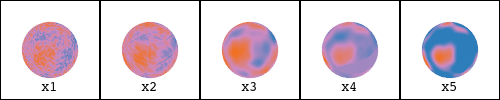

In [11]:
pl = pv.Plotter(shape = (1,5), window_size = (500, 100))

for i in range(Yk0.shape[0]):
    pl.subplot(0,i)
    tmp_mesh = copy.deepcopy(sphere_mesh)
    pl.add_mesh(tmp_mesh, scalars = Yk0[i, :], cmap = bpr, **mesh_aes)
    pl.add_text("x" + str(i + 1), position = "lower_edge", font = "courier", font_size = 6)
    pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

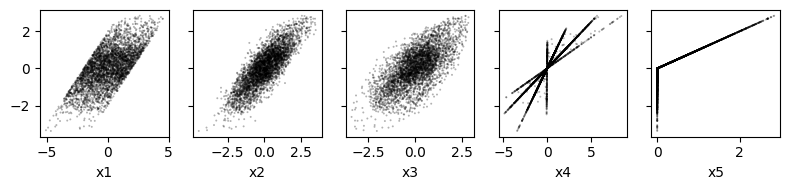

In [12]:
fig, axs = plt.subplots(1,5, figsize = (8,2), sharey=True)

for k in range(Yk0.shape[0]):
    axs[k].scatter(x=Yk0[k,:], y=sphere_mesh['50'], color = 'k', edgecolor = 'none', s=2, rasterized=True, alpha=0.3)
    axs[k].set_xlabel("x" + str(k+1))

plt.tight_layout()

In [13]:
collect_corr_cov = np.zeros((Yk0.shape[0], len(test_ranges)))

for ri, test_range in enumerate(test_ranges):
    Yk0, yk1 = run_wrappers.generate_covariates(curr_map=str(test_range), src_polydata=sphere_mesh, trg_polydata=sphere_mesh, nspins=3000, datasource='grf')

    for k in range(Yk0.shape[0]):
        collect_corr_cov[k, ri] = metrics.metric(Yk0[k,:], sphere_mesh[str(test_range)], 'pearson')

0.1909526515400187
0.680095899862587
0.8591265298545981
0.9258498375350642


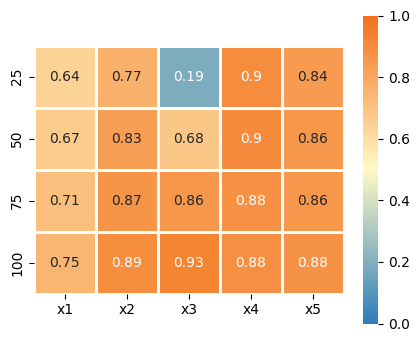

In [14]:
import seaborn as sns

plt.figure(figsize = (5,4))
sns.heatmap(collect_corr_cov.T, cmap = gnrd, \
            xticklabels = ["x" + str(i+1) for i in range(5)],
            yticklabels = test_ranges,
            linewidth = 1, annot = collect_corr_cov.T, \
            linecolor = 'w', vmin=0, vmax = 1, square=True)
plt.show()

## Variography

In [15]:
nh = 25
X = sphere_mesh.points

* distance matrices

In [8]:
import neuromaps.datasets
import nibabel as nb

EDist = helpers.internal_distance_matrix(sphere_mesh.points, "euclidean")

path = neuromaps.datasets.fetch_fslr(density = '4k')['sphere'].L
gimg = nb.load(path)
v,f = gimg.darrays[0].data, gimg.darrays[1].data
GDist = helpers.internal_distance_matrix(v,f, "geodesic")

* binning

In [17]:
import pandas as pd

N = dict.fromkeys(['euclidean', 'geodesic'])
D = {'euclidean': EDist, 'geodesic': GDist}

In [18]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

for method in D:
    max_lag = np.nanmax(D[method])
    
    if method == 'euclidean': 
        tree = KDTree(X)
        spdist = tree.sparse_distance_matrix(tree, max_distance=max_lag, output_type='coo_matrix')
    if method == 'geodesic':
        spdist = coo_matrix(D[method])

    i_idx = spdist.row
    j_idx = spdist.col
    dist_ij = spdist.data
    
    df = pd.DataFrame({
        'h': dist_ij,
    })
    
    bin_edges = np.linspace(0.000001, max_lag, nh + 1)
    df['bins'] = pd.cut(df['h'], bin_edges)

    N[method] = df.groupby('bins')['h'].count().values

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,nh))
cmap_discrete = ListedColormap(colors)

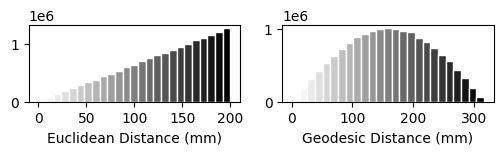

In [20]:
figs, axs = plt.subplots(1,2, figsize = (6,1))

bin_edges = np.linspace(0.000001, np.nanmax(EDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[0].bar(x=bincenters, height=N["euclidean"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[0].set_xlabel("Euclidean Distance (mm)")

bin_edges = np.linspace(0.000001, np.nanmax(GDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[1].bar(x=bincenters, height=N["geodesic"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[1].set_xlabel("Geodesic Distance (mm)")

plt.show()

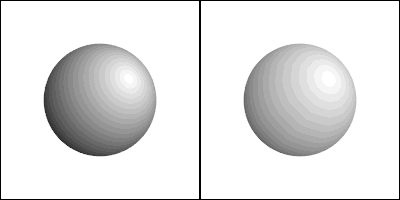

In [21]:
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(shape = (1,2), window_size = (400,200))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_mesh(copy.deepcopy(sphere_mesh), scalars=EDist[20], opacity=1, cmap = cmap_discrete, **mesh_aes)
pl.camera_position = 'yz'

pl.subplot(0,1)
pl.add_mesh(copy.deepcopy(sphere_mesh), scalars=GDist[20], opacity =1, cmap = cmap_discrete, **mesh_aes)

pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

### Theoretical variograms

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap_cont = plt.cm.Blues

colors = cmap_cont(np.linspace(0.25,1,len(np.arange(25,105,5))))
cmap_discrete = ListedColormap(colors)

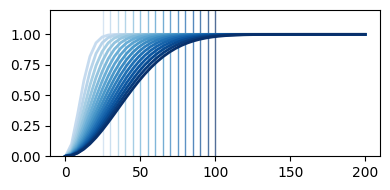

In [9]:
import matplotlib.pyplot as plt
from interpmodules import helpers

plt.figure(figsize = (4,2))


for ri, r in enumerate( np.arange(25,105,5) ):
    x = np.linspace(0,EDist.max())
    
    theoretical = [ helpers.gaussian(h=xi, r=r, c0=1, nugget=0) for xi in x ]

    plt.plot(x, theoretical, color = colors[ri], linewidth=2, zorder = 10)
    plt.axvline(r, color = colors[ri], linewidth = 1, alpha = .7)

plt.ylim([0,1.2])
#plt.fill_betweenx(y=np.linspace(0,1.2), x1=25, x2=100, color='lightgray')

plt.tight_layout()

### Experimental variograms

In [22]:
collect_z_fulldense_expvgm = dict()
collect_z_fullsparse_expvgm = dict()


In [23]:
nh=25
Dist = helpers.internal_distance_matrix(sphere_mesh.points, 'euclidean')
max_lag = Dist.max()
bin_edges = np.linspace(0.000001, max_lag, nh + 1)
bin_centers = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]

#### of GRF instances

In [24]:
from scipy.stats import zscore

for r in test_ranges:
    novariance = zscore(sphere_mesh[str(r)])
    h,ev,nbins = helpers.get_empirical_variogram_fast(x=novariance, X=sphere_mesh.points, D=Dist,\
                                                  nh=nh,h_bounds=bin_edges, method='euclidean')
    
    collect_z_fulldense_expvgm[r] = ev

#### of random samples

In [25]:
# load samples
for r in test_ranges:
    z_fullsparse_expvgm = np.zeros((len(test_percentages), nh, niters))
    for pi,p in enumerate(test_percentages):
        kc,kv,uc,uv = joblib.load(projdir + f'/data/sampling/fsLR-4k_sphere_samp-random_pct-{p}_iters-100.pkl')[1]
        
        for n in range(niters):
            novariance = zscore(sphere_mesh[str(r)][kv[:,n].astype(int)])
            h,ev,nbins = helpers.get_empirical_variogram_fast(x=novariance, X=kc[:,:,n], D=Dist,\
                                                          nh=nh,h_bounds=bin_edges, method='euclidean')
            z_fullsparse_expvgm[pi, :,n] = ev

    collect_z_fullsparse_expvgm[r] = z_fullsparse_expvgm

#### Sample recovery: MAE(random - GRF)

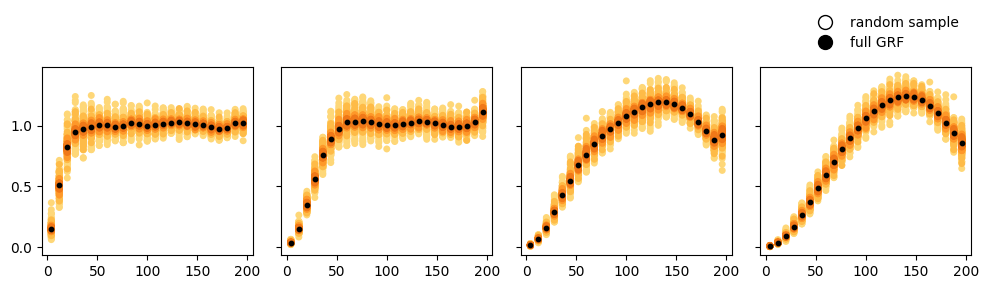

In [26]:
fig, axs = plt.subplots(1, len(test_ranges), figsize = (10,3), sharey = True, sharex=True)

for ri, r in enumerate(test_ranges):

    axs[ri].scatter(bin_centers, collect_z_fulldense_expvgm[r], color = 'k', s=10, zorder =10, rasterized=True)

    for pi, p in enumerate(test_percentages):
        for n in range(niters):
            axs[ri].scatter(bin_centers, collect_z_fullsparse_expvgm[r][pi,:,n], color=pct_colours[pi], \
                            edgecolor = 'none', alpha = 1, s=25, rasterized=True)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markerfacecolor="w", markersize=10, label="random sample"),
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markerfacecolor="k", markersize=10, label="full GRF"),
]

plt.legend(handles=legend_elements, loc = 'lower right', bbox_to_anchor=(1, 1.02), frameon=False)

plt.tight_layout()

* calculate MAE

In [27]:
collect_mae_exp = np.zeros((len(test_percentages), len(test_ranges) * niters))
mae_sampling_expanded = []

In [28]:
for pi, p in enumerate(test_percentages):
    mae_exp = []
    for ri, r in enumerate(test_ranges):
        for n in range(niters):
            gof = np.mean( metrics.metric( collect_z_fullsparse_expvgm[r][pi,:,n], collect_z_fulldense_expvgm[r], 'residual' ) )
            mae_exp.append( gof )
            mae_sampling_expanded.append([gof] * 6)
    collect_mae_exp[pi,:] = mae_exp

#### Model recovery: MAE(fitted - theoretical)

In [29]:
fitted = dict()
theoretical = dict()

In [30]:
# fit each sill-standardized experimental variogram to a gaussian variogram
from scipy.optimize import curve_fit

model = helpers.gaussian

x_long=np.array(bin_centers)
u=bin_centers
nparams = 3

for ri, r in enumerate(test_ranges):
    z_fullsparse_fitvgm = np.zeros((len(test_percentages), nh, niters))
    
    for pi, p in enumerate(test_percentages):
        for n in range(niters):
            
            ev=collect_z_fullsparse_expvgm[r][pi,:,n]
        
            bounds = ([0.00001]*nparams, [np.nanmax(u), np.nanmax(ev), np.nanmax(ev)/nh])
        
            cof, cov = curve_fit(model, u, ev, method = 'trf', p0=bounds[1], bounds = bounds, maxfev=1000)
            v_pred = model(x_long, *cof)
            z_fullsparse_fitvgm[pi, :, n] = v_pred
    
    fitted[r] = z_fullsparse_fitvgm

In [31]:
for ri, r in enumerate(test_ranges):
    theoretical[r] = np.array( [ helpers.gaussian(xi, r, 1, 0) for xi in x_long ] ) 

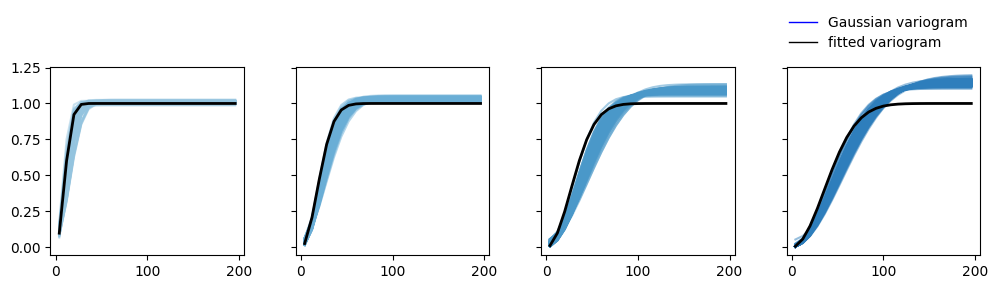

In [32]:
fig, axs = plt.subplots(1, len(test_ranges), figsize = (10,3), sharey = True, sharex=True)

for ri, r in enumerate(test_ranges):
    for pi, p in enumerate(test_percentages):
        
        for n in range(niters):
            axs[ri].plot(x_long, fitted[r][pi, :, n], color = range_colours[ri], alpha = .5, rasterized=True)
    
    axs[ri].plot(x_long, theoretical[r], linewidth =2, color = 'k', rasterized=True)

legend_elements = [
    Line2D([0], [0], marker="none", color="k", linewidth =1, \
           c="blue", markersize=0, label="Gaussian variogram"),
    Line2D([0], [0], marker="none", color="k", linewidth =1, \
           c="k", markersize=0, label="fitted variogram"),
]

plt.legend(handles=legend_elements, loc = 'lower right', bbox_to_anchor=(1, 1.02), frameon=False)

plt.tight_layout()

* calculate MAE

In [33]:
collect_mae_fit = np.zeros((len(test_ranges), len(test_percentages) * niters))
mae_modeling_expanded = []

In [34]:
for ri, r in enumerate(test_ranges):
    mae_fit = []
    for pi, p in enumerate(test_percentages):
        for n in range(niters):

            gof = np.mean( metrics.metric( fitted[r][pi,:,n], theoretical[r], 'residual' ) )
            mae_fit.append( gof )
            mae_modeling_expanded.append([gof] * 6)

    collect_mae_fit[ri,:] = mae_fit

* Plotting MAE sampling vs modeling

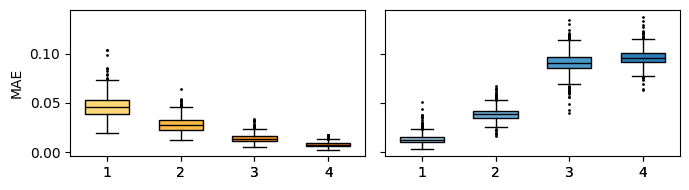

In [35]:
fig, axs = plt.subplots(1,2, figsize = (7,2), sharex=True, sharey=True)

    
bp = axs[0].boxplot(collect_mae_exp.T, widths = 0.6, patch_artist=True, \
            flierprops = {"markerfacecolor": 'k', "mec": 'none', "markersize": 2})

for box, pi in zip(bp["boxes"], range(len(test_percentages))):
    box.set_facecolor(pct_colours[pi])
    box.set_edgecolor("black")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1)

axs[0].set_ylabel("MAE")

bp = axs[1].boxplot(collect_mae_fit.T, widths = 0.6, patch_artist=True, \
            flierprops = {"markerfacecolor": 'k', "mec": 'none', "markersize": 2})

for box, ri in zip(bp["boxes"], range(len(test_ranges))):
    box.set_facecolor(range_colours[ri])
    box.set_edgecolor("black")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1)
    
plt.tight_layout()

## Sampling regime (VSE)

In [10]:
def _coords_icosahedron_to_perfect_sphere(vertices, radius=1.0):
    norms = np.linalg.norm(vertices, axis=1, keepdims=True)
    return radius * vertices / norms

def slerp(p0, p1, num=10):
    """Spherical linear interpolation between two unit vectors."""
    p0 = p0 / np.linalg.norm(p0)
    p1 = p1 / np.linalg.norm(p1)
    omega = np.arccos(np.clip(np.dot(p0, p1), -1.0, 1.0))
    if np.isclose(omega, 0):
        return np.tile(p0, (num, 1))
    sin_omega = np.sin(omega)
    t = np.linspace(0, 1, num)[:, None]
    return (np.sin((1 - t) * omega) / sin_omega) * p0 + (np.sin(t * omega) / sin_omega) * p1

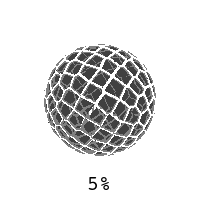

In [11]:
import copy
import pyvista as pv
from scipy.spatial import SphericalVoronoi

pl = pv.Plotter(window_size = (200,200))

ps = [7]
p = 5

desc, sampling = joblib.load(projdir + f'/data/sampling/fsLR-4k_sphere_samp-fibonacci_pct-{p}.pkl')
known_coords, known_verts ,_,_ = sampling

tmp_mesh = copy.deepcopy(sphere_mesh)
#pl.add_mesh(tmp_mesh, color = 'lightgray', opacity = .7, **mesh_aes)
#pl.add_points(known_coords[:,:,0], \
#              point_size = ps[0], color = 'k', show_scalar_bar=False, **point_aes)
pl.add_text(str(p)+"%", position = "lower_edge", font = "courier", font_size = 8)



points = _coords_icosahedron_to_perfect_sphere(vertices=known_coords[:,:,0], radius=1)

#pl.add_points(points, point_size=7, color = 'white', **point_aes)

sphere = pv.Sphere(radius=1.0, theta_resolution=60, phi_resolution=60)
pl.add_mesh(sphere, color="k", opacity=0.5, **mesh_aes)


sv = SphericalVoronoi(points)
sv.sort_vertices_of_regions()

# Add Voronoi edges as spherical arcs
for region in sv.regions:
    verts = sv.vertices[region]
    for i in range(len(verts)):
        j = (i + 1) % len(verts)
        arc = slerp(verts[i], verts[j], num=20)
        line = pv.lines_from_points(arc)
        pl.add_mesh(line, color="white", line_width=3)


pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

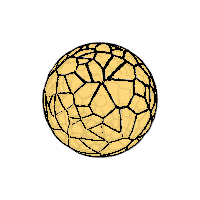

In [14]:
import copy
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

ps = [7]
p = 5

desc, sampling = joblib.load(f'/home/yzhou/gitrepo/interpolate/data/sampling/fsLR-4k_sphere_samp-random_pct-{p}_iters-100.pkl')
known_coords, known_verts ,_,_ = sampling

#tmp_mesh = copy.deepcopy(sphere_mesh)
#pl.add_mesh(tmp_mesh, color = 'dimgray', opacity = .7, **mesh_aes)
#pl.add_points(known_coords[:,:,0], \
#              point_size = ps[0], color = pct_colours[0], show_scalar_bar=False, **point_aes)
#pl.add_text(str(p)+"%", position = "lower_edge", font = "courier", font_size = 8)

points = _coords_icosahedron_to_perfect_sphere(vertices=known_coords[:,:,0], radius=1)

#pl.add_points(points, point_size=7, color = 'white', **point_aes)

sphere = pv.Sphere(radius=1.0, theta_resolution=60, phi_resolution=60)
pl.add_mesh(sphere, color=pct_colours[0], opacity=0.9, **mesh_aes)


sv = SphericalVoronoi(points)
sv.sort_vertices_of_regions()

# Add Voronoi edges as spherical arcs
for region in sv.regions:
    verts = sv.vertices[region]
    for i in range(len(verts)):
        j = (i + 1) % len(verts)
        arc = slerp(verts[i], verts[j], num=20)
        line = pv.lines_from_points(arc)
        pl.add_mesh(line, color="k", line_width=3)


pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

In [15]:
labels, results = joblib.load(projdir + \
f'/results/{datasource}/{strategy}/{space}_50_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')

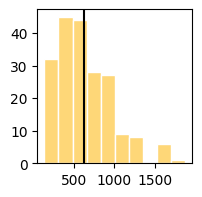

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize = (2,2))
plt.hist(results[0][0][0], edgecolor = 'white', color = pct_colours[0])
plt.axvline(results[0][0][1], color = 'k')

plt.show()

In [36]:
all_standardized_voronoi_se = []
all_voronoi_se = []

voronoi_se = np.zeros((niters, len(test_percentages)))
voronoi_se_zscored = np.zeros((niters, len(test_percentages)))


In [37]:
import joblib

for pi, p in enumerate(test_percentages):
    labels, results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_50_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
    
    for i in range(niters): voronoi_se[i, pi] = results[0][i][2]

    voronoi_se_zscored[:,pi] = zscore( voronoi_se[:,pi] )

    all_standardized_voronoi_se.append(voronoi_se_zscored)
    all_voronoi_se.append(voronoi_se)


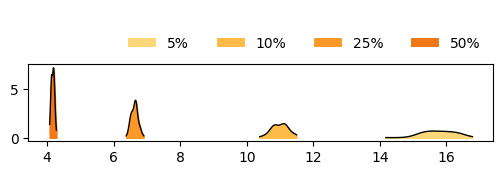

In [38]:
from scipy.stats import zscore, gaussian_kde

plt.figure(figsize = (6,1))
bins = np.histogram_bin_edges(voronoi_se.T, bins=25)

for pi, p in enumerate(test_percentages):

    data = voronoi_se[:,pi]
    
    x = np.linspace(data.min(), data.max(), 50)
    kde = gaussian_kde(data)
    plt.plot(x, kde(x), color = 'k', linewidth=1)

    x = np.linspace(data.min(), data.max(), 50)
    y = gaussian_kde(data)(x)
    
    plt.fill_between(x, y, 0, color = pct_colours[pi], alpha=1)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=pct_colours[pi], label=str(p) + "%")
    for pi, p in enumerate(test_percentages)
]

plt.legend(handles=legend_elements, title=" ", loc='lower right',
bbox_to_anchor=(1, 1.02), frameon=False, ncol = len(test_percentages))
plt.show()

In [39]:
for pi in range(len(test_percentages)):
    print("Sparse sample at: " + str(test_percentages[pi]) + "%")
    print('             mean VSE: ' + str(voronoi_se[:,pi].mean()) )
    print('             variance VSE: ' + str(voronoi_se[:,pi].std()) )

Sparse sample at: 5%
             mean VSE: 15.783256701562804
             variance VSE: 0.48241018293605853
Sparse sample at: 10%
             mean VSE: 10.999516401186577
             variance VSE: 0.2413647999838367
Sparse sample at: 25%
             mean VSE: 6.629554196190411
             variance VSE: 0.10227638511726667
Sparse sample at: 50%
             mean VSE: 4.172370885216229
             variance VSE: 0.046693473895373955


## Performance

In [40]:
concat_everything = pd.DataFrame()

In [41]:
for ri, r in enumerate(test_ranges):

    concat_pct = pd.DataFrame() # rank scores by percentage
    
    for pi, p in enumerate(test_percentages):
        # load results
        labels, results = joblib.load(f'/home/yzhou/gitrepo/interpolate/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
        # join results for all 100 iterations
        concat_iters = pd.concat( [ results[4][i][1] for i in range(niters) ], axis = 1)
        concat_pct = pd.concat( [concat_pct, concat_iters], axis = 1)
    concat_everything = pd.concat( [concat_everything, concat_pct ], axis = 1)

In [42]:
aorder = concat_everything.T.mean().sort_values(ascending=False).index
print("average ranks: ")
print(aorder)

average ranks: 
Index(['krige', 'regkrige', 'idw', 'knn', 'swr', 'rbf'], dtype='object')


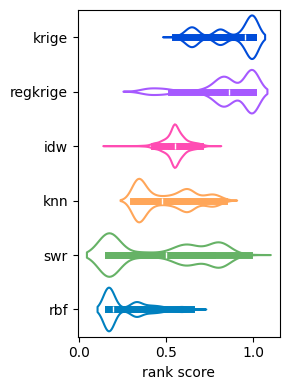

In [43]:
plt.figure(figsize = (3,4))

sns.violinplot(concat_everything.T, order = aorder, orient = 'h', inner = 'box', palette=apal,\
               fill=False, inner_kws=dict(box_width=5, whis_width=5))
plt.xlabel("rank score")

plt.tight_layout()
plt.show()

In [44]:
all_rank_scores = []
long_ranges = []
long_percentages = []

/tmp/ipykernel_66467/3533165864.py:34: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])


idw
0.041840966790914536
0.6665993332862854


/tmp/ipykernel_66467/3533165864.py:34: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])


knn
0.04830225184559822
0.6920903921127319


/tmp/ipykernel_66467/3533165864.py:34: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])


...

swr
0.2862396538257599
0.5483870506286621


/tmp/ipykernel_66467/3533165864.py:34: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])


krige
0.004216761793941259
0.5986256003379822


/tmp/ipykernel_66467/3533165864.py:34: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])


regkrige
0.1029212474822998
0.3306645452976227


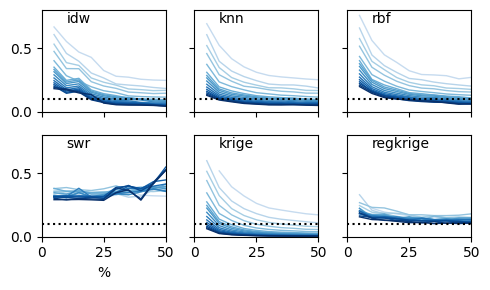

In [18]:
import joblib
import seaborn as sns

import pandas as pd

all_rmse_ran = {}

strategy = 'fibonacci'


fig, axs = plt.subplots(2,3, figsize = (5,3), sharex=True, sharey=True)

for ai, approach in enumerate(approaches):

    row = ai // 3; col = ai % 3
    all_rmse_ran = {}
    
    for pi, p in enumerate(np.arange(5,55,5)):

        list_of_rmse = []
        
        for ri, r in enumerate(np.arange(25,105,5)):
    
            results = joblib.load(projdir + \
            f'/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}_0_all_info.pkl')
                    
            list_of_rmse.append( results['performance'][0].loc['rmse'].loc[approach] )
        
        all_rmse_ran[p] = list_of_rmse
        
    df = pd.DataFrame( all_rmse_ran )
    
    sns.lineplot(df.T, linewidth = 1, palette = colors, dashes = False, legend=False, ax=axs[row,col])
    print(approach)
    print(np.nanmin(df))
    print(np.nanmax(df))
    axs[row,col].axhline(y=0.1, color = 'k', linestyle = 'dotted')
    axs[row,col].set_ylim([0,0.8])
    axs[row,col].set_xlim([0,50])
    axs[row,col].text(x=10, y=0.7, s=approach)
    axs[1,0].set_xlabel("%")
plt.tight_layout()

/tmp/ipykernel_66467/3350781683.py:48: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df_long, x='percentage', y='rmse', hue = 'range', \
/tmp/ipykernel_66467/3350781683.py:48: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df_long, x='percentage', y='rmse', hue = 'range', \
/tmp/ipykernel_66467/3350781683.py:48: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df_long, x='percentage', y='rmse', hue = 'range', \
/tmp/ipykernel_66467/3350781683.py:48: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(df_long, x='percentage', y='rmse', hue = 'range', \
/tmp/ipykernel_66467/335

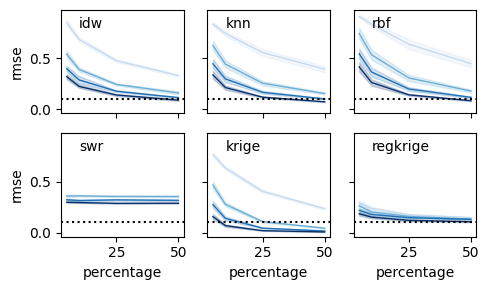

In [22]:
lincmap = plt.get_cmap('Blues')
range_colours = lincmap(np.linspace(0.25, 1, len(test_percentages)))

import pandas as pd
niters=100
strategy='random'
all_rmse_ran = {}

fig, axs = plt.subplots(2,3, figsize = (5,3), sharex=True, sharey=True)

for ai, approach in enumerate(approaches):
    row = ai // 3; col = ai % 3
    
    for ri, r in enumerate(test_ranges):
        all_rmse_pct = {}
        for pi, p in enumerate(test_percentages):
            
            this_box = []
    
            results = joblib.load(projdir + \
                f'/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
            
            for i in range(niters):
                
                this_box.append( results[1][4][i][0].loc['rmse'].loc[approach] )
        
            all_rmse_pct[p] = this_box
    
            tmp = pd.DataFrame(all_rmse_pct).T
    
            tmp_long = (
                tmp
                .reset_index()  # move index (percentage) into a column
                .melt(id_vars='index', var_name='iteration', value_name='rmse')
                .rename(columns={'index': 'percentage'})
            )
            
    
        all_rmse_ran[r] = tmp_long
    
    df = pd.concat(all_rmse_ran)
    df_long = df.reset_index().rename(columns={'index': 'range'})
    df_long['range'] = df_long['level_0']

    #sns.boxplot(df_long, x='percentage', y='rmse', hue = 'range', gap = 2, fliersize = 0, legend=False, palette=range_colours)
    sns.lineplot(df_long, x='percentage', y='rmse', hue = 'range', \
                 palette = range_colours, errorbar = 'sd', linewidth =1, dashes = False, legend=False, ax=axs[row,col])
    axs[row,col].axhline(y=0.1, linestyle='dotted', color='k')
    axs[row,col].text(x=10, y=0.8, s=approach)

plt.tight_layout()

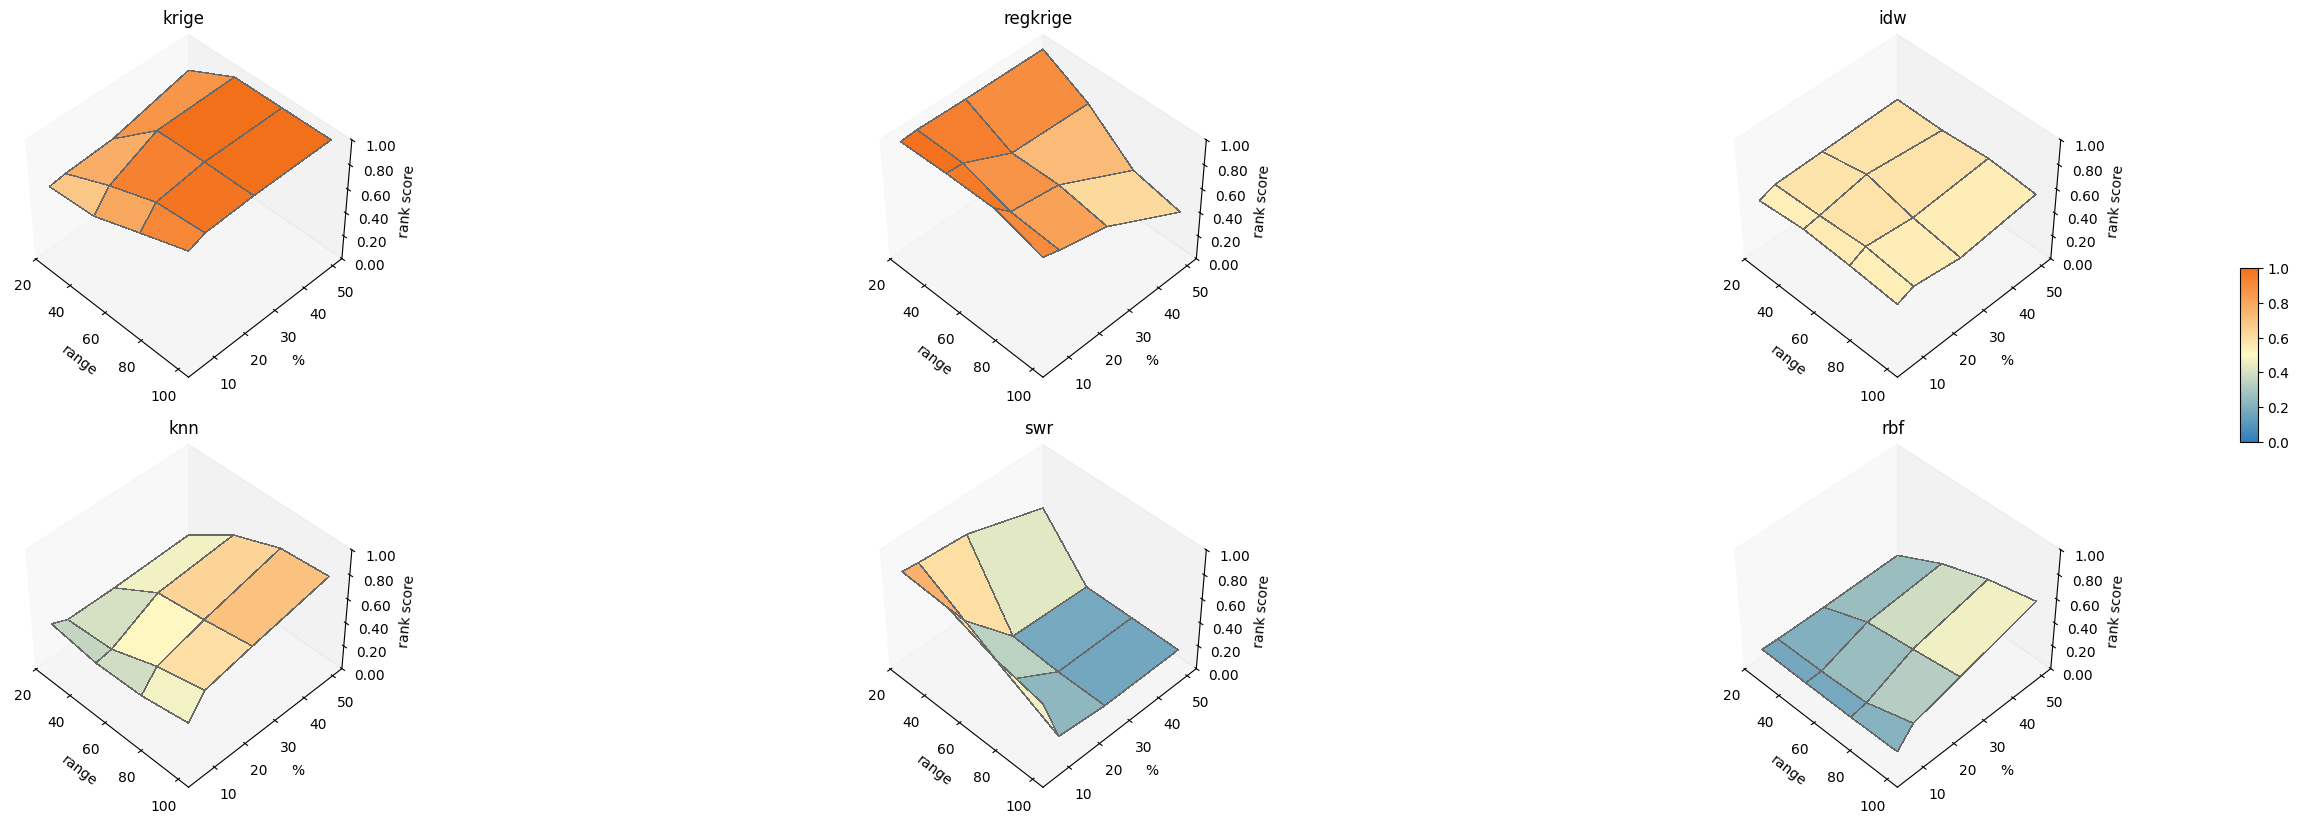

In [45]:
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


approaches_3d = dict.fromkeys(approaches)
fig, axs = plt.subplots(2,3, subplot_kw={"projection": "3d"}, constrained_layout=True, figsize = (8, 6))

for pi, p in enumerate(test_percentages):

    gridplotdata = pd.DataFrame()
    for ri, r in enumerate(test_ranges):

        strategy = 'random'
        
        labels, results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
        concat_rank_scores = pd.concat( [results[4][i][1] for i in range(niters)] , axis = 1 )

        all_rank_scores.append(concat_rank_scores)
        long_ranges.append([r] * 600)
        long_percentages.append([p] * 600)
        gridplotdata[str(r)] = concat_rank_scores.mean(axis=1)
    
    gridplotdata = gridplotdata.reindex(approaches)
    
    for approach in approaches:
        if approaches_3d[approach] == None: approaches_3d[approach] = []
        approaches_3d[approach].append(gridplotdata.loc[approach])

# Make data.
X = test_ranges
Y = test_percentages
X, Y = np.meshgrid(X, Y)

for ai, approach in enumerate(aorder):

    row, col = ai // 3, ai % 3
    
    Z = pd.DataFrame(approaches_3d[approach]).to_numpy()
    
    # Plot the surface.
    surf = axs[row,col].plot_surface(X, Y, Z, vmin = 0, vmax = 1, cmap=gnrd,
                           linewidth=.3, edgecolor = 'dimgray', antialiased=False)
    axs[row,col].grid(False)
    axs[row,col].set_facecolor('none')
    axs[row,col].zaxis.set_major_formatter('{x:.02f}')
    axs[row,col].set_zlim([0,1])
    axs[row,col].set_zlabel('rank score')
    axs[row,col].set_ylabel('%')
    axs[row,col].set_xlabel('range')
    axs[row,col].set_title(approach)
    axs[row,col].view_init(45, -45)


axins = inset_axes(
    axs[-1, -1],
    width="5%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower left",
    bbox_to_anchor=(1.50, 1.0, 1, 1),
    bbox_transform=axs[-1, -1].transAxes,
    borderpad=0,
)
norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)


fig.set_constrained_layout_pads(
    w_pad=0.1,
    h_pad=0.1,
    hspace=0.1,
    wspace=0.1
)
fig.set_size_inches(25, 8)

plt.show()

### 3D heatmap: extended Fibonacci samples

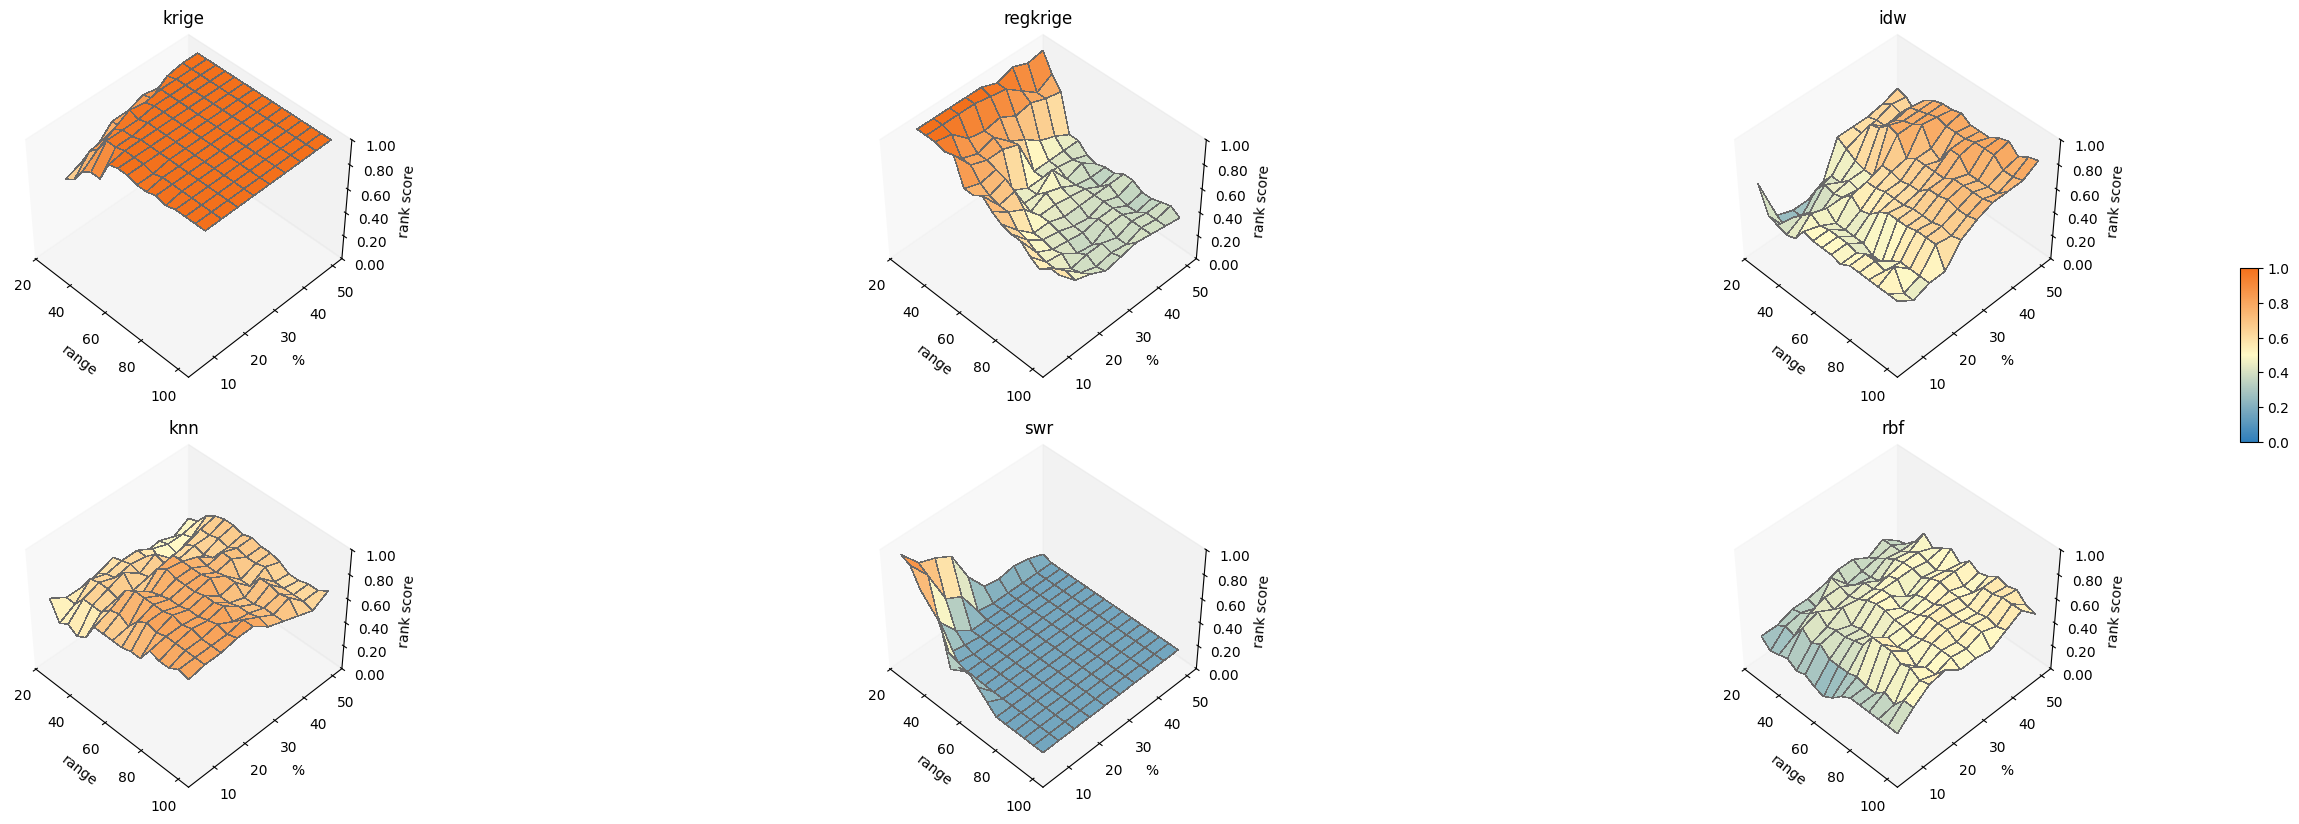

In [47]:
import joblib
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

approaches_3d = dict.fromkeys(approaches)
fig, axs = plt.subplots(2,3, subplot_kw={"projection": "3d"}, constrained_layout=True, figsize = (8, 6))

for pi, p in enumerate(np.arange(5, 55, 5)):

    gridplotdata = pd.DataFrame()
    for ri, r in enumerate(np.arange(25,105,5)):

        strategy = 'fibonacci'
        results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}_0_all_info.pkl')
        concat_rank_scores = results['performance'][1]
        
        gridplotdata[r] = concat_rank_scores
    
    gridplotdata = gridplotdata.reindex(approaches)
    
    for approach in approaches:
        if approaches_3d[approach] == None: approaches_3d[approach] = []
        approaches_3d[approach].append(gridplotdata.loc[approach])

# Make data.
X = np.arange(25,105,5)
Y = np.arange(5,55,5)
X, Y = np.meshgrid(X, Y)

for ai, approach in enumerate(aorder):

    row, col = ai // 3, ai % 3
    
    Z = pd.DataFrame(approaches_3d[approach]).to_numpy()
    
    # Plot the surface.
    surf = axs[row,col].plot_surface(X, Y, Z, vmin = 0, vmax = 1, cmap=gnrd,
                           linewidth=.3, edgecolor = 'dimgray', antialiased=False)
    axs[row,col].grid(False)
    axs[row,col].set_facecolor('none')
    axs[row,col].zaxis.set_major_formatter('{x:.02f}')
    axs[row,col].set_zlim([0,1])
    axs[row,col].set_zlabel('rank score')
    axs[row,col].set_ylabel('%')
    axs[row,col].set_xlabel('range')
    axs[row,col].set_title(approach)
    axs[row,col].view_init(45, -45)


axins = inset_axes(
    axs[-1, -1],
    width="5%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower left",
    bbox_to_anchor=(1.50, 1.0, 1, 1),
    bbox_transform=axs[-1, -1].transAxes,
    borderpad=0,
)
norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.set_constrained_layout_pads(
    w_pad=0.1,
    h_pad=0.1,
    hspace=0.1,
    wspace=0.1
)

fig.set_size_inches(25, 8)
plt.show()

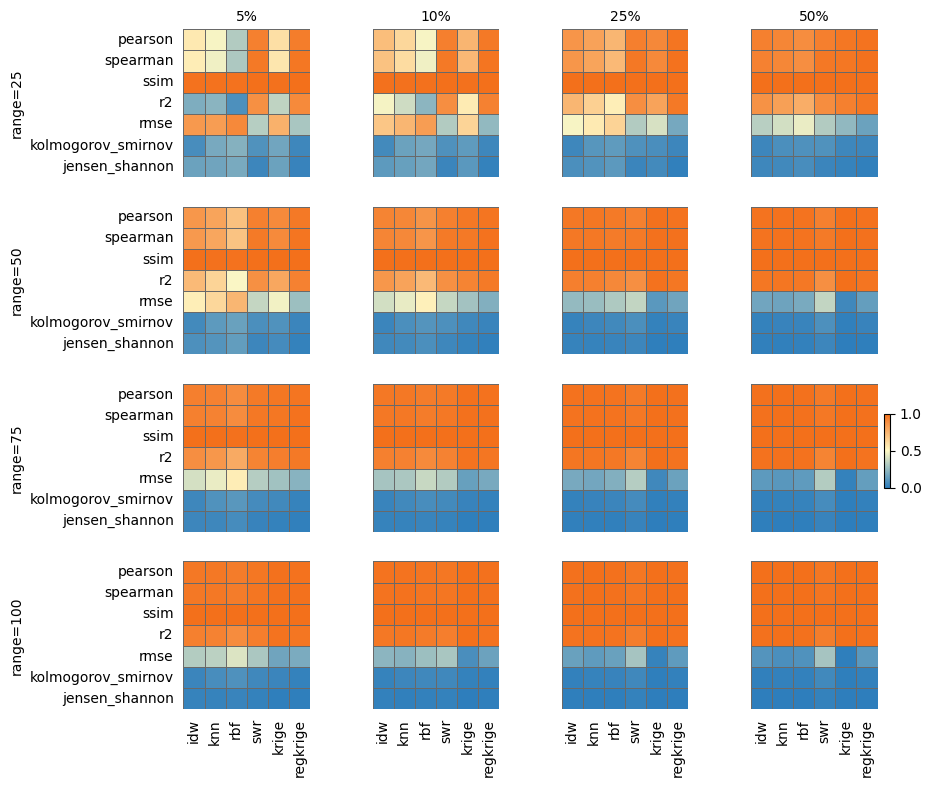

In [49]:
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, axs = plt.subplots(len(test_ranges), len(test_percentages), figsize = (10,10), sharex=True, sharey=True)
strategy = 'random'
for ri, r in enumerate(test_ranges):
    for pi, p in enumerate(test_percentages):
        labels, results = joblib.load(projdir + 
        f'/results/{datasource}/{strategy}/{space}_{str(r)}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
        mean_metric_scores = np.mean( [results[4][i][0].loc[metrics_to_consider[:-1]].T for i in range(niters)], axis = 0)
        
        sns.heatmap(mean_metric_scores.T, yticklabels=metrics_to_consider[:-1], xticklabels = approaches, \
                    cmap = gnrd, vmin =0, vmax = 1, cbar = False,\
                   square=True, linewidth = .5, linecolor = 'dimgray', ax=axs[ri, pi])

        axs[ri,pi].tick_params(
            axis='both',
            which='both',
            bottom=False,
            top=False,
            left=False,
            right=False,
        )
        
        axs[0, pi].set_title(f'{p}%', fontsize = 10)
        axs[ri, 0].set_ylabel(f"range={str(r)}", fontsize = 10)

axins = inset_axes(
    axs[-1,-1],
    width="5%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower left",
    bbox_to_anchor=(1.05, 1.50, 1, 1),
    bbox_transform=axs[-1,-1].transAxes,
    borderpad=0,
)
norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

#plt.tight_layout()
fig.subplots_adjust(right=0.85, bottom = 0.2)
plt.show()

### _Data management_

In [50]:
ranks = pd.concat(all_rank_scores)
ranks_reshaped = pd.lreshape( ranks, {'rank': list(range(100))})

ranks_reshaped['approach'] = list(ranks.index) * 100
ranks_reshaped['percentage'] = np.array( long_percentages ).flatten()
ranks_reshaped['range'] = np.array( long_ranges ).flatten()
ranks_reshaped['mae_sampling'] = np.array( mae_sampling_expanded ).flatten()
ranks_reshaped['mae_modeling'] = np.array( mae_modeling_expanded ).flatten()

In [51]:
concat_long_voronoi = []
concat_vario_voro = []
for j in range(4):
    concat_vario_voro.append( np.array( [ [voronoi_se_zscored[i,j]] * 4 for i in range(100)]).flatten())
    long_voronoi = np.array( [ [voronoi_se_zscored[i,j]] * 24 for i in range(100)])
    long_voronoi = long_voronoi.flatten()
    concat_long_voronoi.append(long_voronoi)

In [52]:
ranks_reshaped['uneven_z'] = np.concatenate( concat_long_voronoi )

In [53]:
ranks_reshaped.head()

,rank,approach,percentage,range,mae_sampling,mae_modeling,uneven_z
0,1.000000,regkrige,5,25,0.046677,0.006267,0.913761
1,0.809524,swr,5,25,0.046677,0.006267,0.913761
2,0.595238,krige,5,25,0.046677,0.006267,0.913761
3,0.500000,idw,5,25,0.046677,0.006267,0.913761
4,0.428571,knn,5,25,0.046677,0.006267,0.913761


In [54]:
#joblib.dump(ranks_reshaped, projdir + '/results/stats/grf_collected_stats_sheet_sill-normalized_all_runs.pkl')